# GPT-2 small, from scratch

Goal: implement GPT-2 small's architecture ourselves, then load the real pretrained weights (HF `gpt2` checkpoint) into it and verify our model produces the same logits/generations as the real thing.

Real GPT-2 small config: `n_layer=12, n_head=12, n_embd=768, vocab_size=50257, block_size=1024`. We'll build with a config object so these aren't hardcoded.

Build order: causal self-attention -> MLP -> transformer block (pre-LN + residuals) -> full model (token+pos embeddings, block stack, final LN, tied lm_head) -> load real weights -> verify.

## Full transformer block schematic

```
Input x  (B, T, n_embd)
   |
   |-----------------------------+
   v                             |
 LayerNorm (ln_1)                |
   v                             |
 CausalSelfAttention             |
   v                             |
 Dropout                         |
   v                             |
   + <---------------------------+   (residual add)
   |
   |-----------------------------+
   v                             |
 LayerNorm (ln_2)                |
   v                             |
 MLP: Linear(n_embd -> 4*n_embd) |
      -> GELU                   |
      -> Linear(4*n_embd -> n_embd)
   v                             |
 Dropout                         |
   v                             |
   + <---------------------------+   (residual add)
   |
   v
Output  (B, T, n_embd)
```

Pre-LN: LayerNorm happens *before* attention/MLP, not after. Each sub-layer (attention, MLP) gets its own residual connection.

Full model = wte(tokens) + wpe(positions) -> stack of n_layer of these blocks -> final ln_f -> lm_head (tied to wte weights).

## Full picture (image)

Same structure as the schematic above, rendered as a diagram: full stack | transformer block | attention detail.


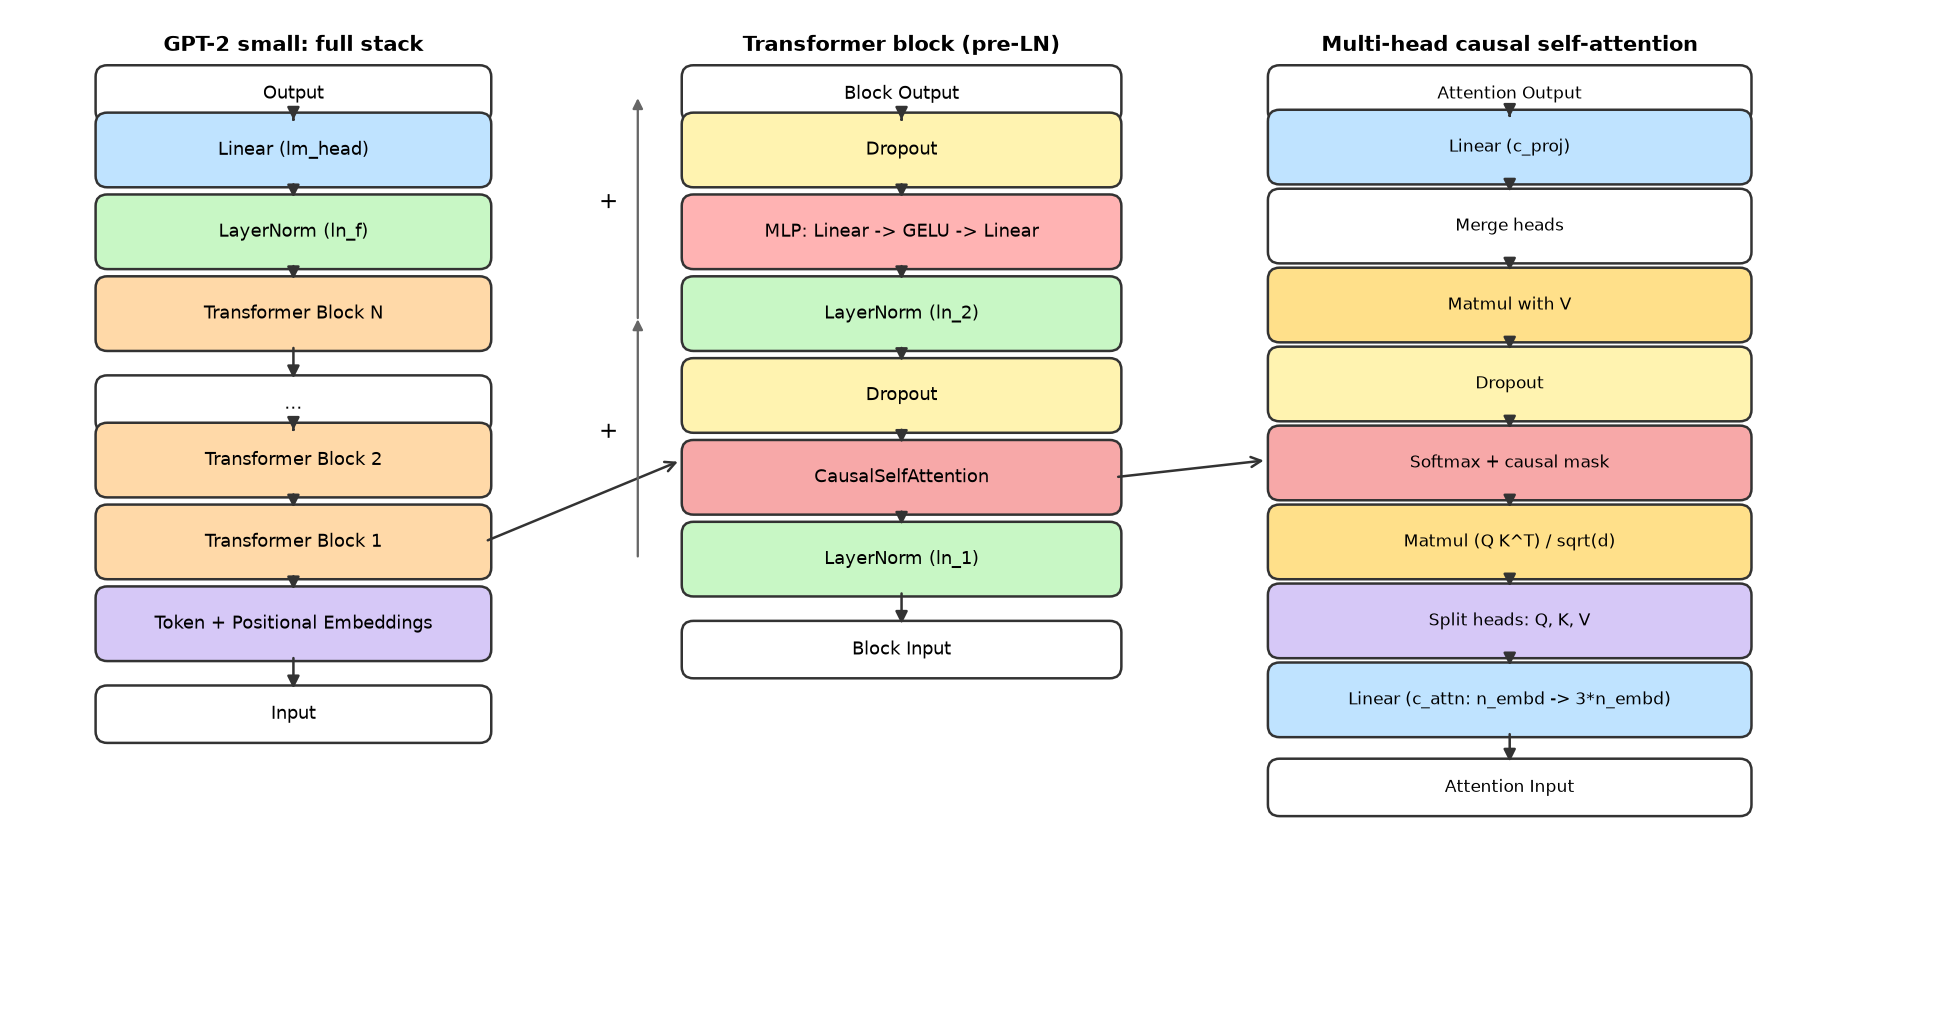

## Causal self-attention

Implement multi-head causal self-attention as an `nn.Module`, matching the way GPT-2 itself does it (this matters later for loading real weights):

- **One combined projection** `c_attn = nn.Linear(n_embd, 3 * n_embd)` producing q, k, v together (not three separate Linear layers) - split the output into q/k/v afterward. This is the actual GPT-2/nanoGPT convention.
- Reshape each of q, k, v from `(B, T, n_embd)` to `(B, n_head, T, head_dim)` so heads are computed in parallel (`head_dim = n_embd // n_head`).
- Scaled dot-product attention with a **causal mask** - position `i` can only attend to positions `<= i`. You can use `F.scaled_dot_product_attention(..., is_causal=True)` or build the mask + softmax manually - your call.
- Merge heads back to `(B, T, n_embd)` and pass through an output projection `c_proj = nn.Linear(n_embd, n_embd)`.

Test with a small toy config first (e.g. `n_embd=8, n_head=2`) on a random input tensor, check the output shape matches the input shape.

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CausalSelfAttention(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        self.d = n_embd
        self.nh = n_head
        self.dk = self.d// self.nh
        self.c_attn = nn.Linear(self.d, 3 * self.d)
        self.c_proj = nn.Linear(self.d, self.d)
        
    def forward(self, x):
        # x: [B, T, d]
        B, T, _ = x.shape

        ### projection
        x = self.c_attn(x) # [B, T, 3 * d]
        Q, K, V = x.split(self.d, dim=-1) 

        ### reshape
        Q = Q.view(B, T, self.nh, self.dk).transpose(1, 2)
        K = K.view(B, T, self.nh, self.dk).transpose(1, 2)
        V = V.view(B, T, self.nh, self.dk).transpose(1, 2) # [B, n, T, dk]

        ### scaled dot product
        attention_z = Q @ K.transpose(-2, -1)/ (self.dk ** .5) # [B, n, T, T]
        mask = torch.tril(torch.ones(T, T)).bool() 
        attention_mask = attention_z.masked_fill(~mask, float("-inf"))
        attention_scores = torch.softmax(attention_mask, dim=-1)
        out = attention_scores @ V  #   [B, n, T, d] 
        # out = F.scaled_dot_product_attention(Q, K, V, is_causal=True)
    
        ### merging
        out = out.transpose(1, 2).contiguous().reshape(B, T, -1) # [B, T, d]
        out = self.c_proj(out) #[B, T, d]

        return out


x = torch.randn([2, 10, 16])
att = CausalSelfAttention(16, 2)
y = att(x)
print(x.shape, y.shape)
    

torch.Size([2, 10, 16]) torch.Size([2, 10, 16])


### Causal self-attention: mechanical checklist

- **Projections**: Q, K, V from input `x` of shape `(B, T, d_model)` - either three `nn.Linear(d_model, d_model)` or one fused `nn.Linear(d_model, 3*d_model)` (`c_attn`) then split. Real GPT-2 uses the fused version, with `bias=True`.
- **Reshape to heads**: `(B, T, d_model)` -> `(B, n_head, T, head_dim)` where `head_dim = d_model // n_head`. Done via `.view()` + `.transpose(1, 2)` - get the order right.
- **Scores**: `Q @ K.transpose(-2, -1) / sqrt(head_dim)` -> shape `(B, n_head, T, T)`.
- **Causal mask**: lower-triangular; `masked_fill` the upper triangle to `-inf` before softmax.
- **Softmax** over the last dim (the keys dim), then `@ V` -> `(B, n_head, T, head_dim)`.
- **Merge heads back**: `.transpose(1, 2)` -> `(B, T, n_head, head_dim)` -> `.reshape(B, T, d_model)`, then output projection (`c_proj`, also `bias=True`).

Two gotchas:
- **Contiguity**: after `.transpose(1, 2)` the tensor isn't contiguous, so a raw `.view()` right after will error. Use `.contiguous()` first, or just use `.reshape()` instead of `.view()` at the split-to-heads and merge-heads-back steps - `.reshape()` copies automatically when needed.
- **Bias**: real GPT-2's `c_attn` and `c_proj` both have `bias=True` - matters when loading real pretrained weights later, since the state dict includes bias tensors too.

### Attention: plain-English naming glossary

(Separate from the code names like `c_attn`/`c_proj` above - this is the descriptive vocabulary for talking about the same pieces out loud.)

- **QKV projection layer** (or *fused projection*) - the single `Linear` that produces Q, K, V together from the input. Code name: `c_attn`.
- **Output projection layer** - the `Linear` applied after merging heads back together, before the residual add. Code name: `c_proj`.
- **Head dimension** - the size of each individual head's slice (`n_embd // n_head`). Code name: `head_dim` (or `dk`/`hs` in some codebases).
- **Number of heads** - how many parallel attention heads. Code name: `n_head`.
- **Embedding dimension** / **hidden dimension** - the model's main width, same value in and out of every layer. Code name: `n_embd` (also called `d_model` in papers/other codebases).

In [4]:
class MLP(nn.Module):
    def __init__(self, n_embd):
        super().__init__()
        self.d = n_embd
        self.expansion_factor = 4
        self.c_fc = nn.Linear(self.d, self.d * self.expansion_factor)
        self.c_proj = nn.Linear(self.d * self.expansion_factor, self.d)
        self.gelu = nn.GELU(approximate="tanh")

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        out = self.c_proj(x)
        return out

x = torch.randn([2, 10, 16])
mlp = MLP(16)
y = mlp(x)
print(x.shape, y.shape)

torch.Size([2, 10, 16]) torch.Size([2, 10, 16])


## MLP

Implement the feed-forward block as an `nn.Module`, matching real GPT-2 naming/shape:

- `c_fc = nn.Linear(n_embd, 4 * n_embd)` - expand to 4x.
- GELU activation. Real GPT-2 uses the **tanh-approximation** GELU, not the exact erf-based one - `nn.GELU(approximate="tanh")` or `F.gelu(x, approximate="tanh")`. Matters later: using the exact version would give slightly different numbers than the real pretrained weights.
- `c_proj = nn.Linear(4 * n_embd, n_embd)` - project back down.

That's it - two Linear layers with a GELU between them, applied independently to every position (same as any `nn.Linear`, only the last dim changes).

Test the same way as attention: random input `(B, T, n_embd)`, check output shape matches.

### MLP: plain-English naming glossary

- **Expand layer** (or *up-projection*) - the first `Linear`, grows `n_embd -> 4*n_embd`. Code name: `c_fc`.
- **Shrink layer** (also just called the *projection layer*, by convention) - the second `Linear`, shrinks back `4*n_embd -> n_embd`. Code name: `c_proj` (same convention as attention's output projection - both are "the layer that shrinks back down to n_embd right before the residual add").
- **Expansion factor** (or *expansion ratio*) - the multiplier between `n_embd` and the MLP's inner width. `4` for GPT-2. Not a fixed constant across architectures - e.g. SwiGLU-based models (LLaMA/Qwen) use a smaller ratio since they have 3 weight matrices instead of 2. In HF's `GPT2Config` this is the `n_inner` field (defaults to `4 * n_embd`).

## Transformer block

Wire `CausalSelfAttention` and `MLP` together with pre-LN + residuals (see the schematic near the top):

- `ln_1 = nn.LayerNorm(n_embd)`, `ln_2 = nn.LayerNorm(n_embd)` - two separate LayerNorms, not shared.
- `attn = CausalSelfAttention(n_embd, n_head)`, `mlp = MLP(n_embd)`.
- Forward: `x = x + attn(ln_1(x))`, then `x = x + mlp(ln_2(x))`.

Test the same way as before - random `(B, T, n_embd)` input, check output shape matches.

In [7]:
class Block(nn.Module):
    def __init__(self, n_embd, n_head):
        super().__init__()
        self.d = n_embd
        self.nh = n_head
        self.attn = CausalSelfAttention(self.d, self.nh)
        self.mlp = MLP(self.d)
        self.ln1 = nn.LayerNorm(self.d)
        self.ln2 = nn.LayerNorm(self.d)

    def forward(self, x):
        x = x + self.attn(self.ln1(x)) 
        x = x + self.mlp(self.ln2(x))
        return x

x = torch.randn([2, 10, 16])
block = Block(16, 2)
y = block(x)
print(x.shape, y.shape)

torch.Size([2, 10, 16]) torch.Size([2, 10, 16])


## Full model: GPT2

Wire everything together into the full model, matching real GPT-2/HF naming (matters for weight loading next):

- `wte = nn.Embedding(vocab_size, n_embd)` - token embeddings.
- `wpe = nn.Embedding(block_size, n_embd)` - positional embeddings (learned, not sinusoidal - GPT-2 specific).
- `h = nn.ModuleList([Block(n_embd, n_head) for _ in range(n_layer)])` - the stack of blocks. Use `nn.ModuleList`, not a plain Python list, so PyTorch tracks the sub-modules' parameters.
- `ln_f = nn.LayerNorm(n_embd)` - final LayerNorm after the last block, before the head.
- `lm_head = nn.Linear(n_embd, vocab_size, bias=False)` - projects back to vocab-size logits.
- **Weight tying**: `lm_head.weight = wte.weight` (literally the same tensor, not a copy) - GPT-2 reuses the token embedding matrix as the output projection. Set this after both are constructed.

Forward, given `idx` of shape `(B, T)` (token ids):
1. `positions = torch.arange(T)`
2. `x = wte(idx) + wpe(positions)` - broadcasts `(T, n_embd)` against `(B, T, n_embd)`.
3. Pass `x` through each block in `h`, in order.
4. `x = ln_f(x)`
5. `logits = lm_head(x)` -> shape `(B, T, vocab_size)`

Test with a small toy config and a random *integer* input (token ids, not floats!) of shape `(B, T)` - check output shape is `(B, T, vocab_size)`.

In [13]:
from dataclasses import dataclass

class GPT2(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.vocab_size = config.vocab_size
        self.max_len = config.block_size
        self.d = config.n_embd
        self.nh = config.n_head
        self.nl = config.n_layer
        #self.dk = self.d //self.nh -> come back to this later

        self.wte = nn.Embedding(self.vocab_size, self.d)
        self.wpe = nn.Embedding(self.max_len, self.d)
        self.ln_f = nn.LayerNorm(self.d)
        self.lm_head = nn.Linear(self.d, self.vocab_size, bias=False)
        self.h = nn.ModuleList()
        for _ in range(self.nl):
            self.h.append(Block(self.d, self.nh))

    def forward(self, idx):
        B, T = idx.shape
        x = self.wte(idx) + self.wpe(torch.arange(T))
        for i in range(self.nl):
            x = self.h[i](x)
        out = self.lm_head(self.ln_f(x))
        return out

@dataclass
class GPTConfig:
    vocab_size: int = 50257
    block_size: int = 1024
    n_layer: int = 12
    n_head: int = 12
    n_embd: int = 768

config = GPTConfig()
token_ids = torch.randint(0, 10, (2, 5)) 
gpt = GPT2(config)
y = gpt(token_ids)
print(token_ids.shape, y.shape)

torch.Size([2, 5]) torch.Size([2, 5, 50257])


## Training: dataset + dataloader

Keep it small so training is actually fast to watch. Use **tiny Shakespeare, character-level** tokenization (nanoGPT's own beginner example) - no BPE tokenizer needed, just build a vocab from the unique characters in the text.

1. **Download the text**: `urllib.request.urlretrieve("https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt", "input.txt")`, then read it into a string.
2. **Build the vocab**: `chars = sorted(set(text))`, then `stoi = {ch: i for i, ch in enumerate(chars)}` and `itos = {i: ch for ch, i in stoi.items()}`. `vocab_size = len(chars)` (will be small, ~65).
3. **Encode the whole text** to a 1D LongTensor of ids using `stoi`.
4. **Train/val split**: first ~90% of the encoded tensor for train, rest for val.
5. **Dataset**: a map-style `Dataset` that, given a starting index, returns `(x, y)` where `x = data[i : i+block_size]` and `y = data[i+1 : i+block_size+1]` - `y` is `x` shifted by one position (next-character prediction). `__len__` should be `len(data) - block_size` (so every `i` has room for a full block ahead).
6. **DataLoader**: wrap it, pick a small `batch_size`, `shuffle=True` for train.

Test: pull one batch, check `x.shape` and `y.shape` are both `(batch_size, block_size)`, and confirm `y` really is `x` shifted by one (e.g. decode a couple of them back to characters and eyeball it).

In [ ]:
import urllib.request
from torch.utils.data import Dataset, DataLoader

# TODO: download + read text

# TODO: build vocab (chars, stoi, itos, vocab_size)

# TODO: encode text to a LongTensor

# TODO: train/val split

class CharDataset(Dataset):
    def __init__(self, data, block_size):
        # TODO
        pass

    def __len__(self):
        # TODO
        pass

    def __getitem__(self, i):
        # TODO
        pass
